In [1]:
from pathlib import Path
import csv
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

In [3]:
manifest_path = Path("/Users/dengtianle/Documents/leo_coding/try-contrastive/data/prepared/dali/manifest.csv")

with manifest_path.open() as f:
    rows = list(csv.DictReader(f))

len(rows), rows[0].keys()

(1600,
 dict_keys(['pair_id', 'pair_type', 'label', 'split', 'dali_id', 'artist', 'title', 'audio_path', 'raw_audio_path', 'melody_path', 'melody_sample_id', 'audio_sample_id', 'melody_start_seconds', 'melody_end_seconds', 'audio_start_seconds', 'audio_end_seconds', 'segment_seconds', 'melody_frame_rate', 'voiced_ratio', 'negative_offset_seconds']))

In [11]:
# Pick a positive or hard negative row
#row = next(r for r in rows if r["pair_type"] == "positive")
row = next(r for r in rows if r["pair_type"] == "hard_negative_same_song")
row

{'pair_id': '5c28ae7381be4de1ba10234762392e63_000025000_c3b5f873b4__hardneg0',
 'pair_type': 'hard_negative_same_song',
 'label': '0',
 'split': 'train',
 'dali_id': '5c28ae7381be4de1ba10234762392e63',
 'artist': 'Sabroso',
 'title': 'De Que Te Vale',
 'audio_path': '/Users/dengtianle/Documents/leo_coding/try-contrastive/data/prepared/dali/audio_16k/5c28ae7381be4de1ba10234762392e63.flac',
 'raw_audio_path': '/Users/dengtianle/Documents/leo_coding/try-contrastive/data/audio/5c28ae7381be4de1ba10234762392e63.mp3',
 'melody_path': '/Users/dengtianle/Documents/leo_coding/try-contrastive/data/prepared/dali/melodies/5c28ae7381be4de1ba10234762392e63_000025000_c3b5f873b4.npz',
 'melody_sample_id': '5c28ae7381be4de1ba10234762392e63_000025000_c3b5f873b4',
 'audio_sample_id': '5c28ae7381be4de1ba10234762392e63_000220000_6d8f39a4d5',
 'melody_start_seconds': '25.000000',
 'melody_end_seconds': '35.000000',
 'audio_start_seconds': '220.000000',
 'audio_end_seconds': '230.000000',
 'segment_seconds': 

In [12]:
audio_path = row["audio_path"]
sr = 16000
start = float(row["audio_start_seconds"])
duration = float(row["segment_seconds"])

waveform, _ = librosa.load(
    audio_path,
    sr=sr,
    mono=True,
    offset=start,
    duration=duration,
)

waveform.shape, waveform.dtype, waveform.min(), waveform.max()

((160000,), dtype('float32'), np.float32(-1.0), np.float32(0.9999695))

In [13]:
display(Audio(waveform, rate=sr))

In [7]:
melody = np.load(row["melody_path"])
melody.files

['frame_times',
 'f0_hz',
 'voiced',
 'frame_rate',
 'start_seconds',
 'duration_seconds']

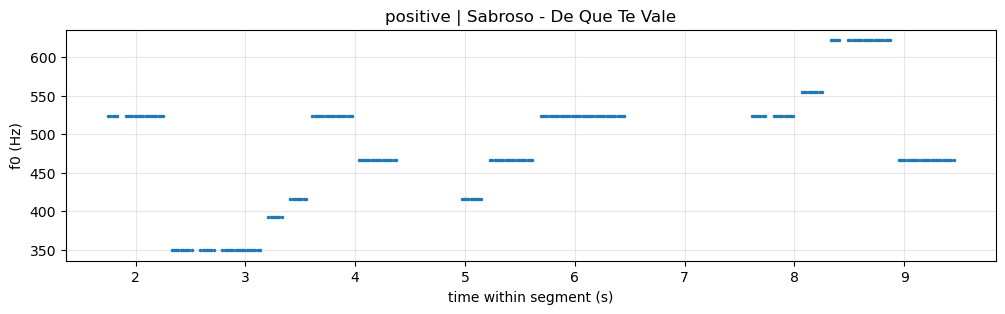

In [8]:
frame_times = melody["frame_times"]
f0_hz = melody["f0_hz"]
voiced = melody["voiced"].astype(bool)

plt.figure(figsize=(12, 3))
plt.plot(frame_times[voiced], f0_hz[voiced], ".", markersize=3)
plt.xlabel("time within segment (s)")
plt.ylabel("f0 (Hz)")
plt.title(f"{row['pair_type']} | {row['artist']} - {row['title']}")
plt.grid(True, alpha=0.3)
plt.show()

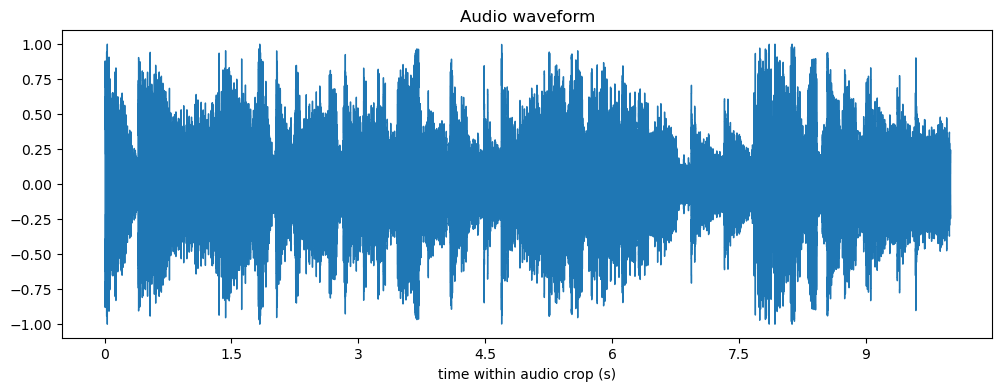

In [9]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(waveform, sr=sr)
plt.xlabel("time within audio crop (s)")
plt.title("Audio waveform")
plt.show()

In [10]:
neg = next(r for r in rows if r["pair_type"] == "hard_negative_same_song")

print("melody:", neg["melody_start_seconds"], neg["melody_end_seconds"])
print("audio: ", neg["audio_start_seconds"], neg["audio_end_seconds"])
print("same song:", neg["dali_id"])
print("label:", neg["label"])

melody: 25.000000 35.000000
audio:  220.000000 230.000000
same song: 5c28ae7381be4de1ba10234762392e63
label: 0
